In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10)

,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


In [3]:
df = df.sort_values('transaction_date').reset_index(drop=True)

train_idx = int(len(df) * 0.8)
train_df  = df.iloc[:train_idx]
test_df   = df.iloc[train_idx:]

print(f'train: {len(train_df)} rows  {train_df["transaction_date"].min()} -> {train_df["transaction_date"].max()}')
print(f'test : {len(test_df)} rows  {test_df["transaction_date"].min()} -> {test_df["transaction_date"].max()}')

train: 960 rows  2022-01-01 00:00:00 -> 2024-06-11 00:00:00
test : 240 rows  2024-06-12 00:00:00 -> 2024-12-31 00:00:00


using a time-ordered split — random split would let the model train on future dates and test on past ones, which doesn't reflect how it would actually get used

In [4]:
cat_feats = ['promotion_type', 'location_type', 'store_size']
num_feats = ['store_id', 'is_weekend', 'is_festival', 'competition_density',
             'year', 'month', 'day_of_week', 'is_month_end']

X_train = train_df[cat_feats + num_feats]
y_train = train_df['items_sold']
X_test  = test_df[cat_feats + num_feats]
y_test  = test_df['items_sold']

In [5]:
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats),
    ('num', StandardScaler(), num_feats)
])

lr_pipe = Pipeline([('pre', pre), ('mdl', LinearRegression())])
rf_pipe = Pipeline([('pre', pre), ('mdl', RandomForestRegressor(n_estimators=100, random_state=42))])

lr_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('mdl', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [6]:
pred_lr = lr_pipe.predict(X_test)
pred_rf = rf_pipe.predict(X_test)

print('Linear Regression')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, pred_lr)):.2f}')
print(f'  MAE : {mean_absolute_error(y_test, pred_lr):.2f}')

print('Random Forest')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, pred_rf)):.2f}')
print(f'  MAE : {mean_absolute_error(y_test, pred_rf):.2f}')

Linear Regression
  RMSE: 27.12
  MAE : 21.05
Random Forest
  RMSE: 30.84
  MAE : 24.24


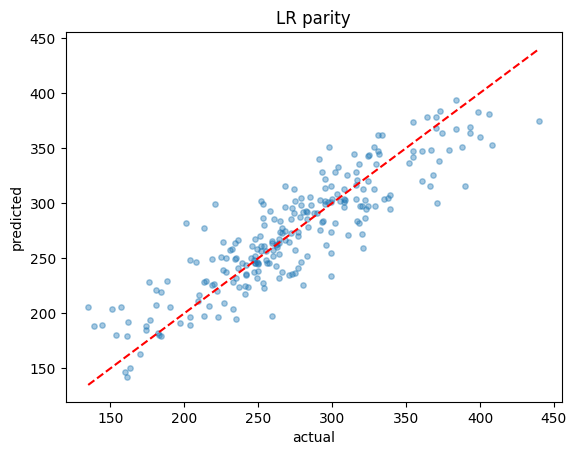

In [7]:
# parity plot - linear regression
plt.scatter(y_test, pred_lr, alpha=0.4, s=15)
lims = [min(y_test.min(), pred_lr.min()), max(y_test.max(), pred_lr.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('actual')
plt.ylabel('predicted')
plt.title('LR parity')
plt.show()

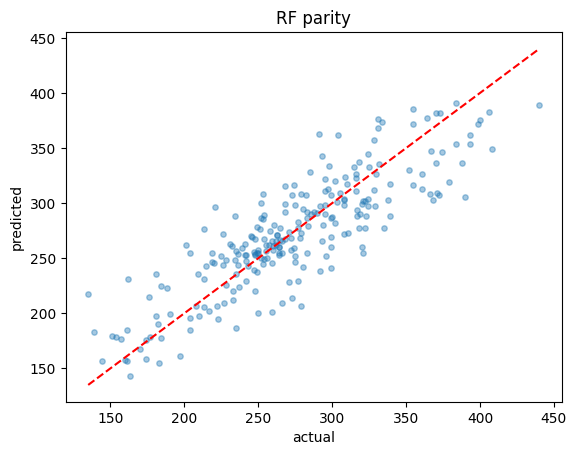

In [8]:
# parity plot - random forest
plt.scatter(y_test, pred_rf, alpha=0.4, s=15)
lims = [min(y_test.min(), pred_rf.min()), max(y_test.max(), pred_rf.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('actual')
plt.ylabel('predicted')
plt.title('RF parity')
plt.show()

In [9]:
ohe_names  = rf_pipe.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(cat_feats).tolist()
feat_names = ohe_names + num_feats

imp_df = pd.DataFrame({'feature': feat_names, 'importance': rf_pipe.named_steps['mdl'].feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 5 features:')
print(imp_df.head(5).to_string(index=False))

Top 5 features:
            feature  importance
        is_festival    0.173473
   store_size_small    0.167683
location_type_urban    0.108378
        day_of_week    0.086316
         is_weekend    0.061208
